# Chapter08: The Normal distribution

```{contents} Table of Contents
:depth: 3
```

In [ ]:
from IPython.display import display, HTML

display(HTML("""
<style>
.callout { padding:12px 14px; border-radius:10px; margin:10px 0; }
.callout.note { background:#eff6ff; border-left:6px solid #3b82f6; }
.callout.warn { background:#fff7ed; border-left:6px solid #f97316; }
.callout.good { background:#ecfdf5; border-left:6px solid #10b981; }
.callout.bad  { background:#fef2f2; border-left:6px solid #ef4444; }
</style>
"""))


display(HTML("""
<style>
/* Base callout */
.callout {
  padding: 12px 14px;
  border-radius: 10px;
  margin: 12px 0;
  line-height: 1.35;
  border-left: 6px solid;
  box-shadow: 0 1px 2px rgba(0,0,0,0.06);
}

/* NOTE variant */
.callout.note {
  background: #eff6ff;         /* light blue */
  border-left-color: #3b82f6;   /* blue */
}

/* Optional: title line inside */
.callout .title {
  font-weight: 700;
  margin-bottom: 6px;
}
</style>
"""))

If $X\sim \mathcal{N}(\mu,\sigma^{2})$ then 

\begin{align}
    supp(X) = (-\infty, \infty)
\end{align}

\begin{align}
    f_{X}(x) = \frac{1}{ \sqrt{2 \pi \sigma^{2}} } e^{ -\frac{1}{2} \left( \frac{x-\mu}{\sigma} \right)^{2}  }
\end{align}

Unique to the Normal distribution, the expected value and the variance involve one parameter each. 

\begin{align}
    \mathbb{E}(X) &= \mu \\ 
    \mathbb{V}(X) &= \sigma^{2} \\ 
\end{align}

The Normal distribution may also be written in terms of **precision**. 
For the Normall, the precision is, $\tau$, equals $1 / \sigma^{2}$ and so then the pdf in terms of precision is 

\begin{align}
    f_{X}(x) = \sqrt{ \frac{\tau}{ 2 \pi}} e^{ -\frac{1}{2} \left[ \tau (x-\mu) \right]^{2}  }
\end{align}



The probability density function for the Normal distribution is what most call "The Bell curve" because of its characteristic shape (see below). 
Most of the probability mass is centered around $\mu$, the expected value, and then probability mass sharply falls away as values in the support move further, in either direction, away from the expected value. 
This is a special property of the Normal distribution. 
The Normal distribution is very good at characterizing experimental quantities that are more or less centered around some single value, called the expected value. 


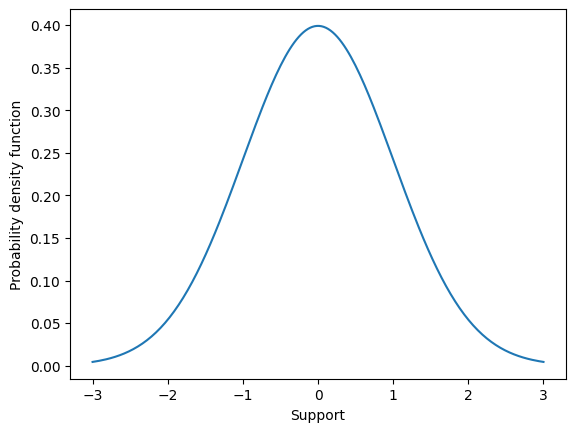

In [6]:
import matplotlib.pyplot as plt 
import numpy as np 

fig,ax = plt.subplots()

mu = 0
sigma = 1 
supp = np.linspace(-3,3,200)
f    = (1 / np.sqrt(2*np.pi*sigma**2) ) * np.exp( -0.5*((supp-mu)/sigma)**2  ) 

ax.plot(supp,f)
ax.set_xlabel("Support")
ax.set_ylabel("Probability density function")
plt.show()

One way to characterize this "most values lie near the expected value" property is, given $X \sim \mathcal{N}(0,1)$ to compute the probability that values fall one, two, and three standard deviations away from $\mu$. 
This illustrates an important numerical skill as well. 
Because the Normal distribution is a continuous random variable, the probability that $X$ falls within one standard deviation is computed as 

\begin{align}
    P(  -\sigma < X-\mu < \sigma ) &= \int_{-\sigma}^{\sigma} f_{X}(x) \; dx \\ 
                                   &= \int_{-\sigma}^{\sigma} \frac{1}{ \sqrt{2 \pi \sigma^{2}} } e^{ -\frac{1}{2} \left( \frac{x-\mu}{\sigma} \right)^{2}  } \; dx\\
\end{align}

This integral has no closed-form solution (ie. there exists no anti-derivative). We must then solve this integral by numerical integration. 
Numerical integration techniques are often called *quadrature* and can be found packaged in Python scipy. 

In [17]:
from scipy.integrate import quad

def pdf_normal(x,mu,sigma):
    f    = (1 / np.sqrt(2*np.pi*sigma**2) ) * np.exp( -0.5*((x-mu)/sigma)**2  ) 
    return f

mu    = 0 
sigma = 1
    
result, err = quad( lambda x: pdf_normal(x, mu, sigma), a=-sigma,b=sigma  )
print(result)

0.682689492137086


We find that $P(  -\sigma < X-\mu < \sigma ) \approx 0.68$. 
In other words, when we assume $X$ has a normal distribution then we assume that the probability a value falls within on standard deviation equals 0.68. 

Lets investigate the probability that a value falls within two standard deviations as well as graph the probability that a value falls within $z$ standard deviations for z from 1/10 to 3. 

In [18]:
result, err = quad( lambda x: pdf_normal(x, mu, sigma), a=-2*sigma,b=2*sigma  )
print(result)

0.9544997361036417


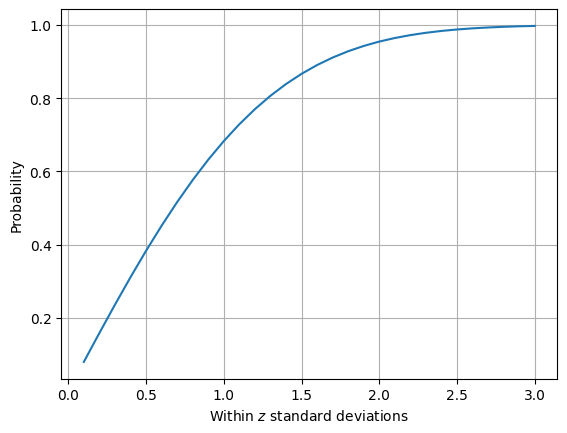

In [15]:
probs = [] 
z_vals = np.linspace(0.1,3,30)
for z in z_vals:
    result, err = quad( lambda x: pdf_normal(x, mu, sigma), a=-z*sigma,b=z*sigma  ) 
    probs.append(result)

fig,ax = plt.subplots()

ax.plot(z_vals, probs)
ax.grid([0.5,1,1.5,2,2.5,3])
ax.set_xlabel(r"Within $z$ standard deviations")
ax.set_ylabel("Probability")

plt.show()

## Standard normal

Though there are an infinite number of Normal distributions (because there are an infinite number of values for $\mu$ and for $\sigma$, the most important set of parameters are $\mu = 0$ and $\sigma^{2}=1$. This is because of another special property of the Normal distribution related to translation and scaling. 

If $X \sim \mathcal{N}(0,1)$ then we say that the random variable $X$ has a *standard normal distribtuion*.
For a standard normal distribution, the expected value is zero, approximately 66% of $x$ values are expected to lie within one standard deviation of zero, 95% are expected to lie within two standard deviations, and 99% within three standard deviations. 

The standard normal is so important because of the Normal distributions ability to easily translate and scale. 


## Translation

Consider $X \sim \mathcal{N}(\mu,\sigma^{2})$ and the transformed random variable $Y = X + c$.
Then $Y  \sim \mathcal{N}(\mu+c,\sigma^{2}) $,. In other words, moving by a constant $c$ just shifts the Normal density over by c units. 

Lets see why. 

\begin{align}
   F_{Y}(y) = P(Y \le y) &= P(X+c \le y) \\ 
                          & = P(X \le y-c) \\ 
                          &= F_{X}( y-c )   \\
\end{align}

To obtain the pdf, we can take the derivative using the chain rule. 
\begin{align}
    f_{Y}(y) = \frac{d}{dy} F_{Y}(y) &= \frac{d}{dx}  F_{X}( y-c ) \frac{dx}{dy} (y-c ) \\
            &= f_{X}(y-c) \cdot 1 \\ 
            &= f_{X}(y-c)\\
            &= \frac{1}{ \sqrt{2 \pi \sigma^{2}} } e^{ -\frac{1}{2} \left( \frac{(y-c)-\mu}{\sigma} \right)^{2}  }\\
            &= \frac{1}{ \sqrt{2 \pi \sigma^{2}} } e^{ -\frac{1}{2} \left( \frac{(y-(\mu+c)}{\sigma} \right)^{2}  }
\end{align}

Importantly, this means that if we want to construct a random variable $X \sim \mathcal{N}(\mu,\sigma^{2})$ we can begin with a random variable $ Y \sim \mathcal{N}(0,\sigma^{2})$ and translate by the constant $\mu$, or 

\begin{align}
    X &= \mu + Y \\ 
    Y &\sim \mathcal{N}(0,\sigma^{2})
\end{align}

We can look at this pdf graphically as well to see it shift over. 


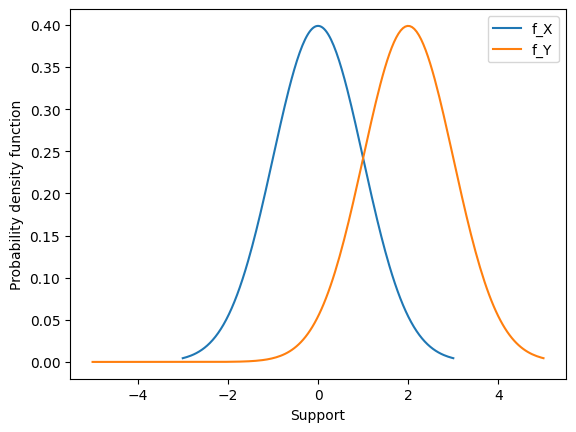

In [3]:
import matplotlib.pyplot as plt 
import numpy as np 

fig,ax = plt.subplots()

mu    = 0
sigma = 1 
supp  = np.linspace(-3,3,200)
f     = (1 / np.sqrt(2*np.pi*sigma**2) ) * np.exp( -0.5*((supp-mu)/sigma)**2  ) 

ax.plot(supp,f, label = "f_X")

mu    = 0
sigma = 1 
C     = 2 
supp = np.linspace(-5,5,200)
f    = (1 / np.sqrt(2*np.pi*sigma**2) ) * np.exp( -0.5*((supp-(mu+C))/sigma)**2  ) 

ax.plot(supp,f, label = "f_Y")

ax.set_xlabel("Support")
ax.set_ylabel("Probability density function")
ax.legend()
plt.show()

## Scaling 

Consider $X \sim \mathcal{N}(\mu,\sigma^{2})$ and the transformed random variable $Y = cX$.
Then $Y  \sim \mathcal{N}(\mu,c^{2}\sigma^{2}) $. In other words, multiplying by a constant $c$ streches/shrinks the Normal density over by c *squared* units. 

Lets see why. 

\begin{align}
   F_{Y}(y) = P(Y \le y) &= P(cX \le y) \\ 
                          & = P(X \le y/c) \\ 
                          &= F_{X}( y/c )   \\
\end{align}

To obtain the pdf, we can take the derivative using the chain rule. 
\begin{align}
    f_{Y}(y) = \frac{d}{dy} F_{Y}(y) &= \frac{d}{dx}  F_{X}( y/c ) \frac{dx}{dy} (y/c ) \\
            &= f_{X}(y/c) \cdot 1/c \\ 
            &= f_{X}(y/c)\\
            &= \frac{1}{ \sqrt{2 \pi \sigma^{2}} } \frac{1}{c} e^{ -\frac{1}{2} \left( \frac{(y/c)-\mu}{\sigma} \right)^{2}  }\\
            &= \frac{1}{ \sqrt{2 \pi \sigma^{2} c^{2}} } e^{ -\frac{1}{2} \left( \frac{ y- c \mu}{c \sigma} \right)^{2}  } \\
            &= \frac{1}{ \sqrt{2 \pi (c\sigma)^{2} } } e^{ -\frac{1}{2} \left( \frac{y- c\mu}{c \sigma} \right)^{2}  } \\
\end{align}

**Scaling is trickier.**

When we multiply by a constant we modify both the expected value $\mu$ and the variance $\sigma^{2}$.
For example, suppose we start with $Y \sim \mathcal{N}(\mu,1)$. 
When we multiply the random variable $Y$ by the constant $\sigma$ we change both the expected value and variance. 

\begin{align}
    X &= \sigma Y \\ 
    Y &\sim \mathcal{N}(\mu,1)
\end{align}

Then 
\begin{align}
    X \sim \mathcal{N}( \mu \sigma, \sigma^{2} )
\end{align}

Lets look at this effect through simulation. 

5.9369860579544405
9.166812022780505


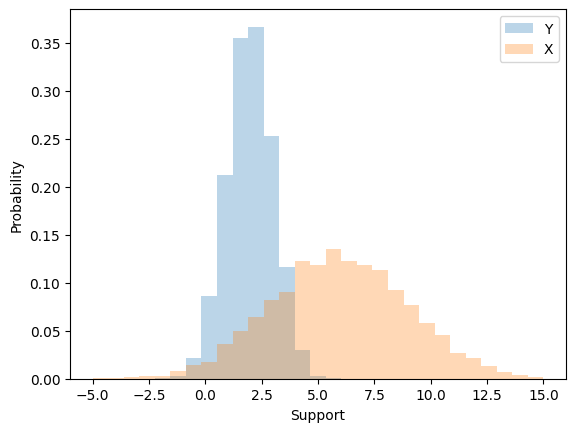

In [16]:
import numpy as np

mu=2
sigma = 3

simulate_Y = np.random.normal( mu, 1, size=4000 )
X = simulate_Y*sigma

import matplotlib.pyplot as plt 

print( np.mean(X) )
print(np.var(X))

fig,ax = plt.subplots()
ax.hist(simulate_Y,np.linspace(-5,15,30),alpha=0.3,  density=True, label="Y")
ax.hist(X         ,np.linspace(-5,15,30),alpha=0.3,  density=True, label="X")

ax.set_xlabel("Support")
ax.set_ylabel("Probability")

ax.legend()
plt.show()

## Uncentered characterization of the Normal 

To create a random variable $X \sim \mathcal{N}(\mu,\sigma^{2})$ we can first start with a random variable $Z \sim \mathcal{N}(0,1)$, scale it by $\sigma$ \textbf{first} and then translate by $\mu$. 
That is, 

\begin{align}
    Z \sim \mathcal{N}(0,1)\\ 
    X = \mu + \sigma \cdot Z \\ 
    X \sim \mathcal{N}(\mu,\sigma^{2})
\end{align}

Note that the order of scaling and translation is important. 
If instead we translated first and then scaled we would not arrive at a Normal density with $\mu$ and $\sigma^{2}$. 

\begin{align}
    Z &\sim \mathcal{N}(0,1)\\ 
    Y &= \mu + Z \\ 
    Y &\sim \mathcal{N}(\mu,1)\\
    \\
    X &= \sigma Y \\ 
    X &\sim \mathcal{N}( \sigma \mu,\sigma^{2})
\end{align}



1.9742709136128025
9.209312063206927


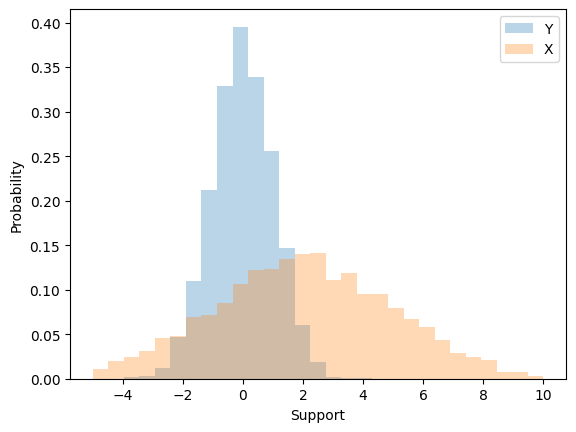

In [19]:
import numpy as np

mu    = 2
sigma = 3

simulate_Z = np.random.normal( 0, 1, size=4000 )
X = mu + simulate_Z*sigma

import matplotlib.pyplot as plt 

print( np.mean(X) )
print( np.var(X) )

fig,ax = plt.subplots()
ax.hist(simulate_Z,np.linspace(-5,10,30),alpha=0.3,  density=True, label="Y")
ax.hist(X         ,np.linspace(-5,10,30),alpha=0.3,  density=True, label="X")

ax.set_xlabel("Support")
ax.set_ylabel("Probability")

ax.legend()
plt.show()

## The mean has a distribution

In statistical inference you'll learn about convergence properties and how they lead towards the Central limit theorem (CLT). Here, we'll gain intuition for the CLT via simulation and learn how to use. 

### Statistical setup

When we collect a dataset, $\mathcal{D} = ( x_{1},x_{2},x_{3}, \cdots, x_{n} )$ it is the job of the statistician to impose a model for how that data was generated (called the **data generating mechanism**) and draw conclusions from a combinaton of data and model. 

The most frequent method for imposing a model is to assume that your data points were generated from a sequence of random variables. 


*Example 1:*
Suppose that every week we select and test 10 patients from a hospital that has 800 in attendance for influenza, recording the number of positive tests from those 10 individuals. 
Our dataset could look something like this $\mathcal{D} = ( 3, 8, 4, 6, 4, 3, 4, 2, 3, \cdots )$

Hospital decision makers may ask "What it the probability that a patient tests positive for influenza over these weeks at the hospital?". This is the job of the statsitican to impose a model and draw conclusions about the probability of a positive test. 

We may decide that every data point was generated by an experiment which can be well represented by a Binomial distribution. In other words, we might assume the following model

\begin{align}
    X_{1} &\sim \text{Binomial}(10, p) \\ 
    X_{2} &\sim \text{Binomial}(10, p) \\ 
    X_{3} &\sim \text{Binomial}(10, p) \\ 
    &\vdots\\
    X_{n} &\sim \text{Binomial}(10, p) 
\end{align}

This can be written in shorthand (X_{1}, X_{2}, \cdots, X_{n} \sim \text{Binomial}(10,p)).
Then, our job is to draw a conclusion from *this model*. We have imposed a specific structure on how we assume that the dataset was generated. 

However, because we have assumed that our dataset is genertaed by this set of random variables then any function of these random variables too has a probability distribution. 

For example, 
The mean is by definition 

\begin{align}
    \bar{X} = \frac{1}{n} \left(X_{1} + X_{2} + \cdots + X_{n} \right)
\end{align}

and because each individual $X$ is a random variable then the mean too can be considered a random variable.
This must mean it has its own distribution. 
To investigate what that distribution looks like we can simulate from a sequennce of binomial densities, compute the mean, and plot a histogram. 


(array([  2.,   3.,   3.,   4.,   5.,  14.,  16.,  20.,  20.,  41.,  53.,
         56.,  71.,  72., 114., 138., 127., 144., 130., 167., 145., 155.,
        145., 129., 116., 121.,  90.,  86.,  63.,  59.,  32.,  43.,  25.,
         27.,  18.,  18.,   8.,   6.,   7.,   1.,   3.,   1.,   1.,   1.]),
 array([0.675     , 0.70056818, 0.72613636, 0.75170455, 0.77727273,
        0.80284091, 0.82840909, 0.85397727, 0.87954545, 0.90511364,
        0.93068182, 0.95625   , 0.98181818, 1.00738636, 1.03295455,
        1.05852273, 1.08409091, 1.10965909, 1.13522727, 1.16079545,
        1.18636364, 1.21193182, 1.2375    , 1.26306818, 1.28863636,
        1.31420455, 1.33977273, 1.36534091, 1.39090909, 1.41647727,
        1.44204545, 1.46761364, 1.49318182, 1.51875   , 1.54431818,
        1.56988636, 1.59545455, 1.62102273, 1.64659091, 1.67215909,
        1.69772727, 1.72329545, 1.74886364, 1.77443182, 1.8       ]),
 <BarContainer object of 44 artists>)

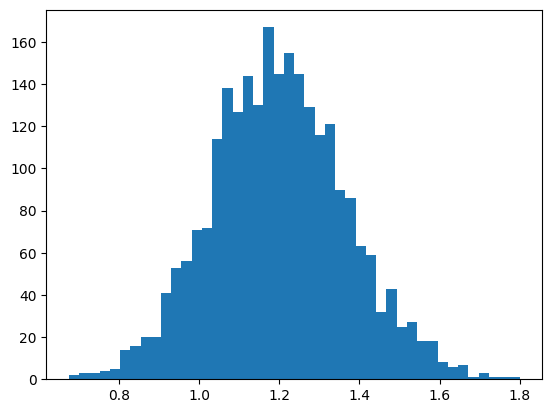

In [9]:
import numpy as np 

number_of_data_points = 40
p = 0.12
N = 10 

number_of_experiments = 2500

collect_mean = [] 
for n in range(number_of_experiments):
    datapoints = np.random.binomial( N, p, size=number_of_data_points )
    mean = np.mean(datapoints)
    collect_mean.append(mean)

import matplotlib.pyplot as plt 

plt.hist( collect_mean, int(np.sqrt(2000)) , density=True )
plt.

## Central limit theorem

### statement 
### simulation 
### why normal?
### why clt


In [ ]:
Homework introuces montecarlo simulation 
Using root finding to compute wuantiles 

The njoint probability
MVN

Random walk
Propject is Gaussian Process regression
